<a href="https://colab.research.google.com/github/dronerace14-lgtm/UAS-Klasifikasi-Sampah-Organik-dan-Anorganik-Menggunakan-Metode-Convolutional-Neural-Network-CNN-/blob/main/UAS%20Klasifikasi%20Sampah%20Organik%20dan%20Anorganik%20Menggunakan%20Metode%20Convolutional%20Neural%20Network%20(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset (1).zip


In [37]:
import zipfile

with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [28]:
import os

print(os.listdir('/content/dataset'))

['organik', 'anorganik']


In [29]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_data = datagen.flow_from_directory(
    '/content/dataset',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    '/content/dataset',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

In [ ]:
print("Jumlah data training :", train_data.samples)
print("Jumlah data validasi :", val_data.samples)

print("\nLabel kelas:")
print(train_data.class_indices)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

# Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(2,2))

# Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(2,2))

# Layer 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(2,2))

# Fully Connected Layer
model.add(Flatten())

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

In [30]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9549 - loss: 0.1307 - val_accuracy: 0.7412 - val_loss: 1.0577
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9543 - loss: 0.1266 - val_accuracy: 0.7682 - val_loss: 1.0116
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9644 - loss: 0.0942 - val_accuracy: 0.7871 - val_loss: 1.0847
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9697 - loss: 0.0822 - val_accuracy: 0.7763 - val_loss: 1.4178
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9744 - loss: 0.0680 - val_accuracy: 0.7978 - val_loss: 1.1705
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9751 - loss: 0.0710 - val_accuracy: 0.7628 - val_loss: 1.5574
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9792 - loss: 0.0566 - val_accuracy: 0.7628 - val_loss: 1.7659
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9798 - loss: 0.0637 - val_accuracy: 0.7655 - val_loss:

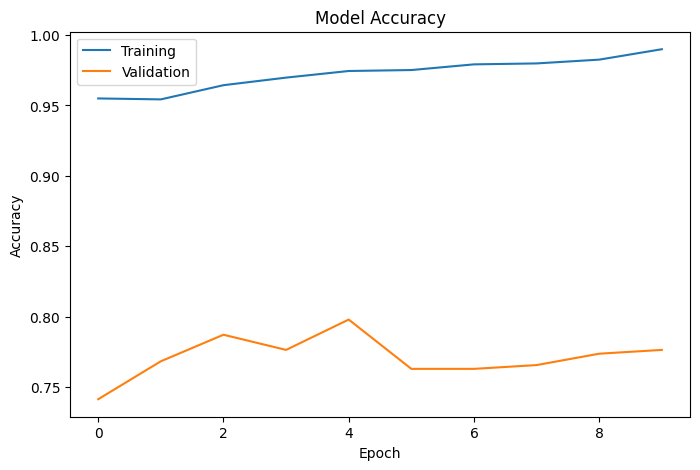

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend([
    'Training',
    'Validation'
])

plt.show()

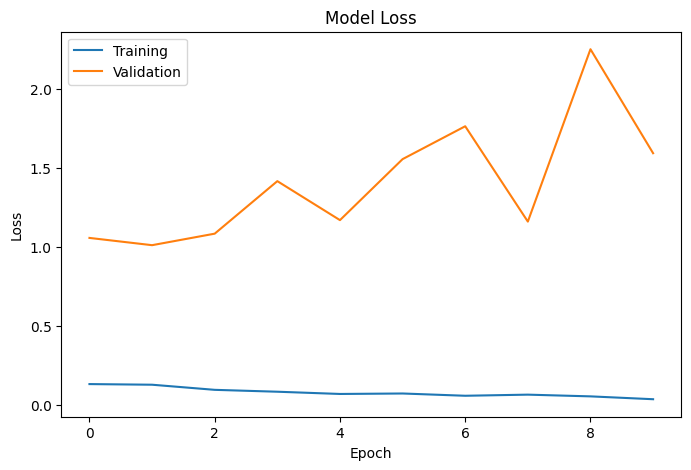

In [32]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend([
    'Training',
    'Validation'
])

plt.show()

In [33]:
loss, accuracy = model.evaluate(val_data)

print("Loss :", loss)
print("Accuracy :", accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 299ms/step - accuracy: 0.7763 - loss: 1.5950
Loss : 1.5949620008468628
Accuracy : 0.7762803435325623


In [34]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import numpy as np

In [35]:
val_data.reset()

predictions = model.predict(val_data)

predicted_classes = (predictions > 0.5).astype(int)

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 409ms/step


In [38]:
cm = confusion_matrix(
    val_data.classes,
    predicted_classes[:len(val_data.classes)]
)

print(cm)

[[116  62]
 [113  80]]


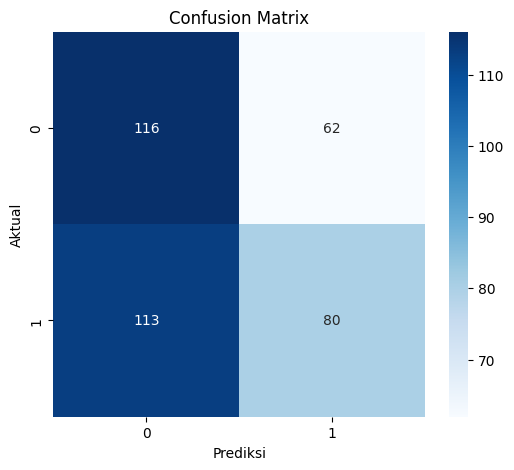

In [39]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')

plt.show()

In [40]:
print(
    classification_report(
        val_data.classes,
        predicted_classes[:len(val_data.classes)]
    )
)

              precision    recall  f1-score   support

           0       0.51      0.65      0.57       178
           1       0.56      0.41      0.48       193

    accuracy                           0.53       371
   macro avg       0.53      0.53      0.52       371
weighted avg       0.54      0.53      0.52       371



In [41]:
print(val_data.shuffle)

True


In [42]:
val_data = datagen.flow_from_directory(
    '/content/dataset',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 371 images belonging to 2 classes.


In [43]:
predictions = model.predict(val_data)

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 435ms/step


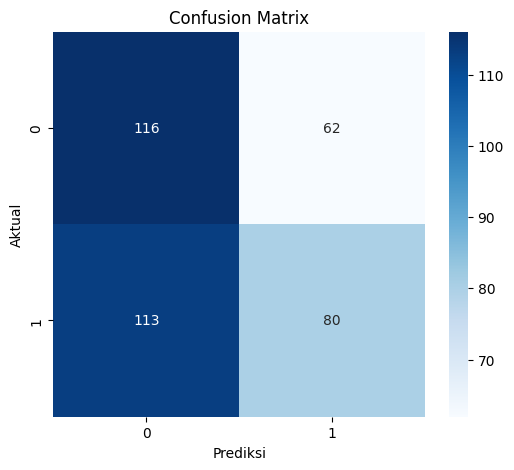

In [45]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')

plt.show()

In [46]:
print(val_data.shuffle)

False


In [47]:
print(predictions.shape)

(371, 1)


In [48]:
print(predictions[:10])

[[1.1899250e-09]
 [4.9349313e-05]
 [9.1884125e-05]
 [3.0485862e-03]
 [2.2964328e-04]
 [1.7506374e-01]
 [7.0707011e-07]
 [1.6872766e-05]
 [4.0560943e-05]
 [9.8659408e-01]]


In [49]:
import numpy as np

predicted_classes = (predictions > 0.5).astype(int)

print(predicted_classes[:10])

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [1]]


In [50]:
print("Jumlah prediksi :", len(predicted_classes))
print("Jumlah label asli :", len(val_data.classes))

Jumlah prediksi : 371
Jumlah label asli : 371


In [51]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    val_data.classes,
    predicted_classes
)

print("Accuracy Manual =", acc)

Accuracy Manual = 0.7762803234501348


In [52]:
print(train_data.class_indices)

{'anorganik': 0, 'organik': 1}


In [53]:
model.save('model_sampah.h5')

In [54]:
from google.colab import files

files.download('model_sampah.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
from google.colab import files

uploaded = files.upload()

Saving plastic87.jpg to plastic87.jpg


In [79]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    'plastic87.jpg',
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = img_array / 255.0

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
[[0.36598578]]


In [80]:
if prediction[0][0] > 0.5:
    print("Sampah Organik")
else:
    print("Sampah Anorganik")

Sampah Anorganik


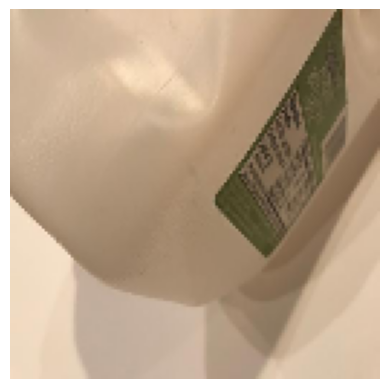

In [81]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img = image.load_img(
    'plastic87.jpg',
    target_size=(128,128)
)

plt.imshow(img)
plt.axis('off')
plt.show()

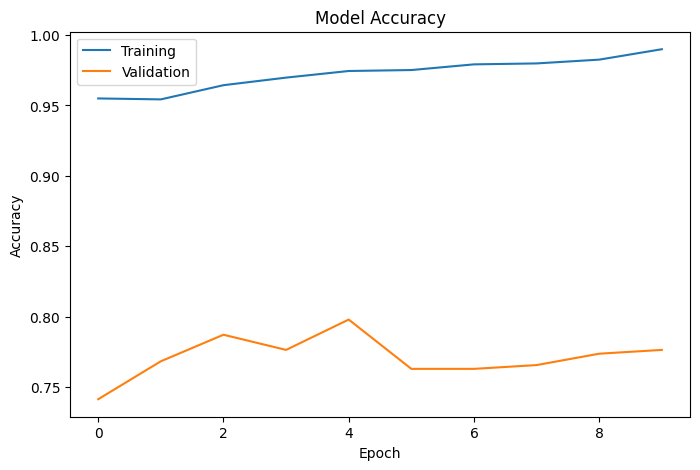

In [66]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Training','Validation'])

plt.savefig('accuracy.png')
plt.show()

In [67]:
from google.colab import files
files.download('accuracy.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

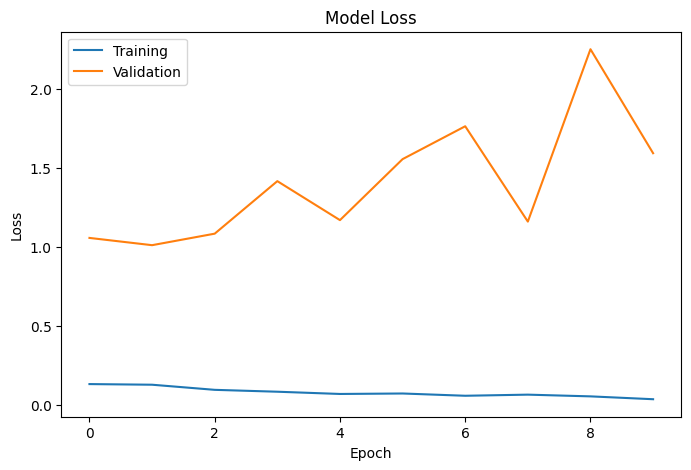

In [68]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Training','Validation'])

plt.savefig('loss.png')
plt.show()

In [69]:
files.download('loss.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
plt.savefig('confusion_matrix.png')

<Figure size 640x480 with 0 Axes>

In [72]:
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>